<a href="https://colab.research.google.com/github/gdhameja1/ML/blob/ML_ALgo/K_Means_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('Customer_Demographics.csv')

In [ ]:
df.head()

,Name,Age,Salary
0,Varun Gupta,28,105000
1,Aditya Kumar,30,135000
2,Anjana Singh,30,91500
3,Anirudha Parsewar,29,90000
4,Vatsal Mishra,43,225000


Text(0, 0.5, 'Salary')

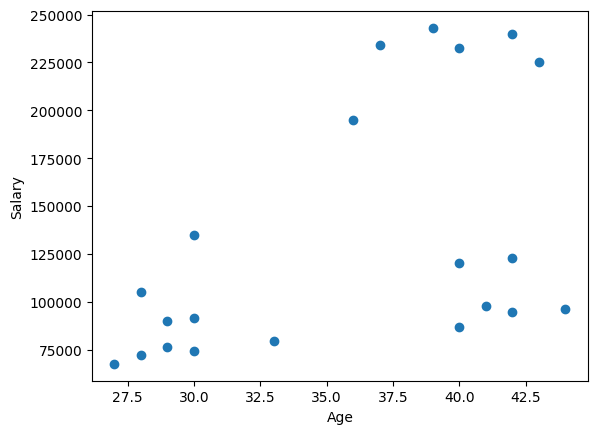

In [ ]:
plt.scatter(df.Age,df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')

In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Salary']])
y_predicted

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [ ]:
df['cluster']=y_predicted
df.head()

,Name,Age,Salary,cluster
0,Varun Gupta,28,105000,0
1,Aditya Kumar,30,135000,2
2,Anjana Singh,30,91500,0
3,Anirudha Parsewar,29,90000,0
4,Vatsal Mishra,43,225000,1


In [ ]:
km.cluster_centers_

array([[3.34166667e+01, 8.59375000e+04],
       [3.95000000e+01, 2.28250000e+05],
       [3.73333333e+01, 1.26000000e+05]])

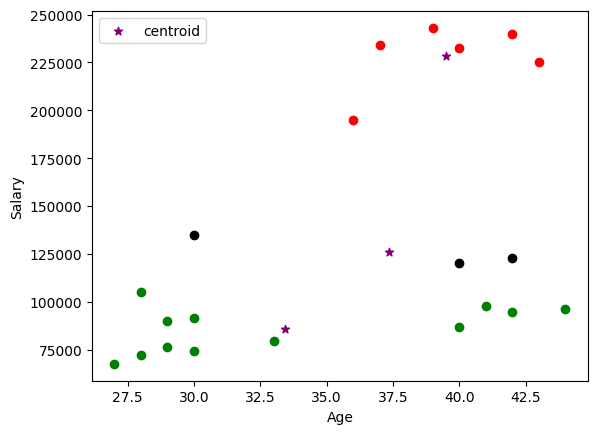

In [ ]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Salary'],color='green')
plt.scatter(df2.Age,df2['Salary'],color='red')
plt.scatter(df3.Age,df3['Salary'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

# Fit the scaler on both 'Age' and 'Salary' together
scaler.fit(df[['Age', 'Salary']])

# Transform 'Age' and 'Salary'
df[['Age', 'Salary']] = scaler.transform(df[['Age', 'Salary']])

In [ ]:
df

,Name,Age,Salary,cluster
0,Varun Gupta,0.058824,0.213675,2
1,Aditya Kumar,0.176471,0.384615,2
2,Anjana Singh,0.176471,0.136752,0
3,Anirudha Parsewar,0.117647,0.128205,0
4,Vatsal Mishra,0.941176,0.897436,1
5,Vibhav Bhasin,0.764706,0.940171,1
6,viswanath perla mallikajuna,0.882353,0.982906,1
7,Kushagra Anand,0.705882,1.000000,1
8,Varuni Jalali,0.588235,0.948718,1
9,Sumani Goyal,0.529412,0.726496,1


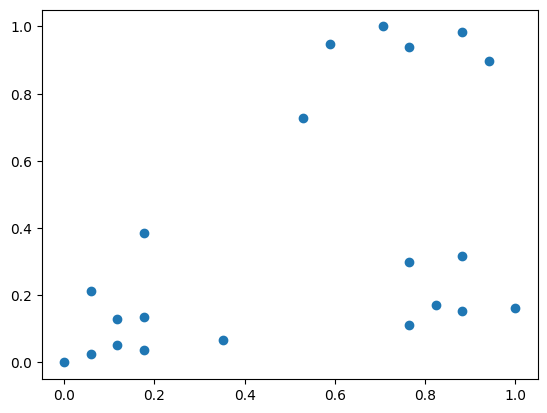

In [ ]:
plt.scatter(df.Age,df['Salary'])

In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Salary']])
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [ ]:
df['cluster']=y_predicted
df.head()

,Name,Age,Salary,cluster
0,Varun Gupta,0.058824,0.213675,1
1,Aditya Kumar,0.176471,0.384615,1
2,Anjana Singh,0.176471,0.136752,1
3,Anirudha Parsewar,0.117647,0.128205,1
4,Vatsal Mishra,0.941176,0.897436,0


In [ ]:
km.cluster_centers_

array([[0.73529412, 0.91595442],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

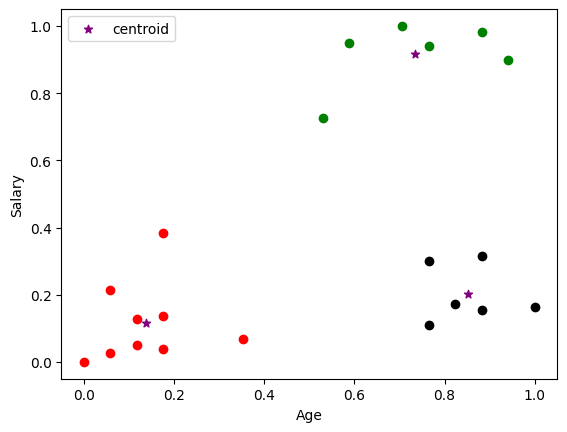

In [ ]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Salary'],color='green')
plt.scatter(df2.Age,df2['Salary'],color='red')
plt.scatter(df3.Age,df3['Salary'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k,)
    km.fit(df[['Age','Salary']])
    sse.append(km.inertia_)

NameError: name 'k_rng' is not defined

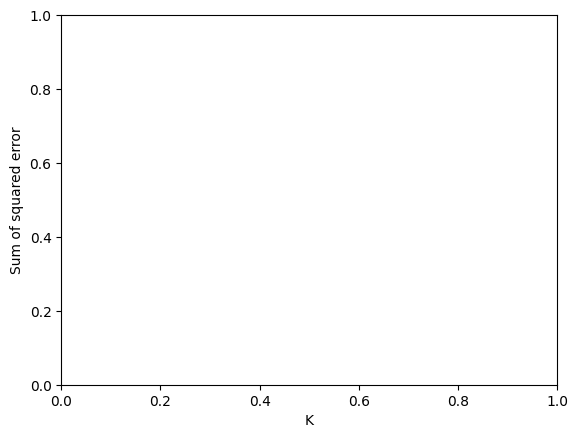

In [ ]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
df.head()

,Name,Age,Salary,cluster
0,Varun Gupta,0.058824,0.213675,0
1,Aditya Kumar,0.176471,0.384615,0
2,Anjana Singh,0.176471,0.136752,0
3,Anirudha Parsewar,0.117647,0.128205,0
4,Vatsal Mishra,0.941176,0.897436,1


In [ ]:
# Inverse transform 'Age' and 'Salary' back to original values
df[['Age', 'Salary']] = scaler.inverse_transform(df[['Age', 'Salary']])
print(df)

                           Name   Age    Salary  cluster
0                   Varun Gupta  28.0  105000.0        0
1                  Aditya Kumar  30.0  135000.0        0
2                  Anjana Singh  30.0   91500.0        0
3             Anirudha Parsewar  29.0   90000.0        0
4                 Vatsal Mishra  43.0  225000.0        1
5                 Vibhav Bhasin  40.0  232500.0        1
6   viswanath perla mallikajuna  42.0  240000.0        1
7                Kushagra Anand  39.0  243000.0        1
8                 Varuni Jalali  37.0  234000.0        1
9                  Sumani Goyal  36.0  195000.0        1
10               Amritesh Khare  27.0   67500.0        0
11                   Rahul Sahu  28.0   72000.0        0
12           Manali Chakraborty  29.0   76500.0        0
13                 shikha yadav  30.0   74250.0        0
14                  Ashish Jain  33.0   79500.0        0
15                  Saurabh Pal  41.0   97500.0        2
16                Manish Mishra

In [ ]:
df.to_excel('profiling.xlsx', index=False)